In [1]:
import xarray as xr 
from dask.distributed import Client, LocalCluster
import glob
import numpy as np
from tqdm.notebook import tqdm
import dask.bag as db

In [2]:

cluster = LocalCluster(n_workers=32, memory_limit='4GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 128.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39715,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36153,Total threads: 1
Dashboard: http://127.0.0.1:39463/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:40511,


In [3]:
main_path_data = '/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily'
files_u850 = sorted(glob.glob(f"{main_path_data}/u850/*"))
files_v850 = sorted(glob.glob(f"{main_path_data}/v850/*"))
files_slp = sorted(glob.glob(f"{main_path_data}/slp/*"))
all_files = [files_u850, files_v850, files_slp]

# Make yearly files

In [ ]:
def get_data(year):
    ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_u850 if f'{year:.0f}' in file], dim='time')
    ds_year.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/yearly/u850_{year:.0f}_era5_1deg_daily_NH.nc')


years = np.arange(1940,2025,1)
for year in tqdm(years):
    get_data(year)


In [12]:
def get_data(year):
    ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_v850 if f'{year:.0f}' in file], dim='time')
    ds_year.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/v850/yearly/v850_{year:.0f}_era5_1deg_daily_NH.nc')


years = np.arange(1940,2025,1)
for year in tqdm(years):
    get_data(year)

  0%|          | 0/85 [00:00<?, ?it/s]

In [4]:
def get_data(year):
    ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_slp if f'{year:.0f}' in file], dim='time')
    ds_year.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/slp/yearly/slp_{year:.0f}_era5_1deg_daily_NH.nc')


years = np.arange(1940,2025,1)
for year in tqdm(years):
    if year not in [1943, 1966]:
        continue
    get_data(year)

  0%|          | 0/85 [00:00<?, ?it/s]

# Combine all files

In [4]:
ds_slp = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/slp/yearly/*.nc',engine='h5netcdf')
ds_u850 = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/yearly/*.nc',engine='h5netcdf')
ds_v850 = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/v850/yearly/*.nc',engine='h5netcdf')

In [5]:
ds_all = xr.Dataset(dict(slp=ds_slp.msl, u850=ds_u850.u, v850=ds_v850.v)).to_array('var_name')

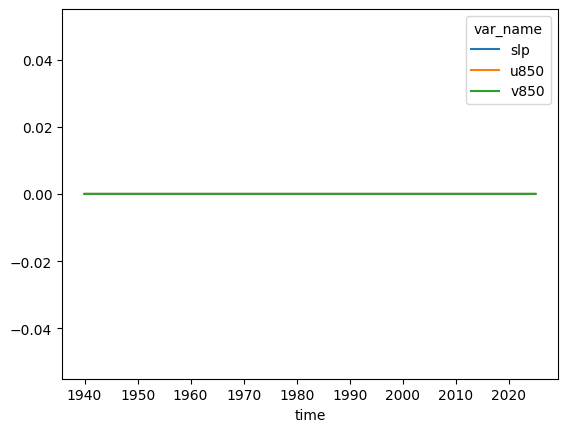

In [6]:
ds_all.isnull().sum(['longitude','latitude']).plot(hue='var_name')

In [7]:
ds_all_mean = ds_all.mean('time').compute()
ds_no_mean = ds_all - ds_all_mean
ds_std = ds_no_mean.std().compute()

In [8]:
ds_std = ds_no_mean.weighted(np.cos(np.deg2rad(ds_no_mean.latitude))).std(['longitude','latitude', 'time']).compute()

In [10]:
ds_out = xr.Dataset(dict(data_normed = ds_no_mean/ds_std,
                         std_value = ds_std,
                         mean_value = ds_all_mean)).transpose('time','var_name','latitude','longitude')

from zarr.codecs import BloscCodec

compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
space_size = 'x'.join(list(np.array(ds_out.data_normed.shape[-2:]).astype(str)))
ds_out.chunk(time=365).to_zarr(f"/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr", 
               encoding={"data_normed": {"compressors": (compressor,)},
                         "mean_value": {"compressors": (compressor,)},
                         "std_value": {"compressors": (compressor,)},
                         "longitude": {"compressors": (compressor,)},
                         "latitude": {"compressors": (compressor,)},
                         "time": {"compressors": (compressor,)},
                         "var_name": {"compressors": (compressor,)},
                         })


/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/zarr/core/array.py:4699: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  serializer = VLenUTF8Codec()
/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:43: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/zarr/api/asynchronous.py:229: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [16]:
pr = xr.open_dataarray('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')

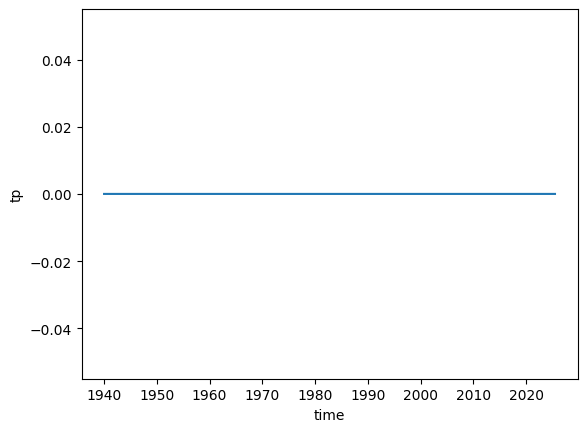

In [17]:
pr.isnull().plot()

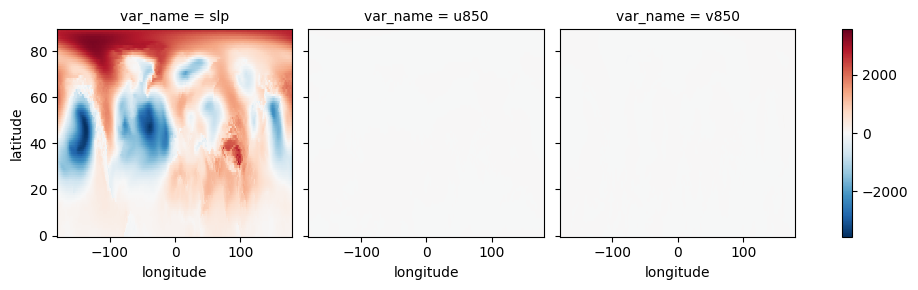

In [16]:
(ds_all.isel(time=0)-ds_all_mean).plot(col='var_name')

In [22]:
ds_ref = xr.open_zarr('/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_128x512_.zarr/')

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:43: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [23]:
ds_ref

<xarray.Dataset> Size: 30GB
Dimensions:      (time: 23011, var_name: 5, latitude: 128, longitude: 512)
Coordinates:
  * time         (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
  * latitude     (latitude) float64 1kB 0.3516 1.055 1.758 ... 88.24 88.95 89.65
  * var_name     (var_name) object 40B 'slp' 'u850' 'v850' 'z500' 't850'
  * longitude    (longitude) float64 4kB 0.0 0.7031 1.406 ... 357.9 358.6 359.3
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 30GB dask.array<chunksize=(256, 1, 64, 64), meta=np.ndarray>
    std_value    (var_name) float32 20B dask.array<chunksize=(1,), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 1MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>

In [ ]:
ds = xr.open_zarr('/Data/gfi/users/rogui7909/data/ERA5')

In [6]:
ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_slp if f'{year:.0f}' in file], dim='time')


ValueError: cannot reindex or align along dimension 'latitude' because the (pandas) index has duplicate values

In [ ]:
ds_u850 = xr.concat(results, dim='time').chunk(time=256)

ds_u850_mean = ds_u850.mean('time').compute()

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 46.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:

all_ds = []
for year in tqdm(years):
    all_ds.append(xr.concat([xr.open_dataset(file, chunks =dict(time=1)) for file in files_u850 if f'{year:.0f}' in file], dim='time'))

  0%|          | 0/86 [00:00<?, ?it/s]

OSError: [Errno -101] NetCDF: HDF error: '/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/u850_2025_04_23_era5_1deg_daily.nc'

In [7]:
ds_u850 = xr.concat(all_ds, dim='time')

In [ ]:
ds_u850_mean = ds_u850.mean('time').load()

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 45.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [10]:
xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/u850_1976_01_01_era5_1deg_daily.nc')

<xarray.Dataset> Size: 263kB
Dimensions:    (latitude: 90, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    time       datetime64[ns] 8B ...
Data variables:
    u          (latitude, longitude) float64 259kB ...

In [ ]:
ds = xr.open_mfdataset(all_files, combine='nested', concat_dim=['var_name','time'], parallel=True)

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 38.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
